In [6]:
from statsmodels.tsa.ar_model import AutoReg
import time
from ctw.series import AR
import numpy as np

coeffs = [0.5, 0.3, 0.1, 0.05]
ar = AR(p=4, coeffs=coeffs, sigma=1.0, n_sample=30000)
data = [x for x in ar]

start_time = time.time()
times = []
errors = []
for i in range(len(data)):
    observed_data = data[:i]
    if len(observed_data) > 10:
        model = AutoReg(observed_data, lags=4)
        model_fit = model.fit()
        params = model_fit.params
        errors.append(np.abs(params[1] - coeffs[0]) + np.abs(params[2] - coeffs[1]) + np.abs(params[3] - coeffs[2]) + np.abs(params[4] - coeffs[3]))
        end_time = time.time()
        times.append(end_time - start_time)

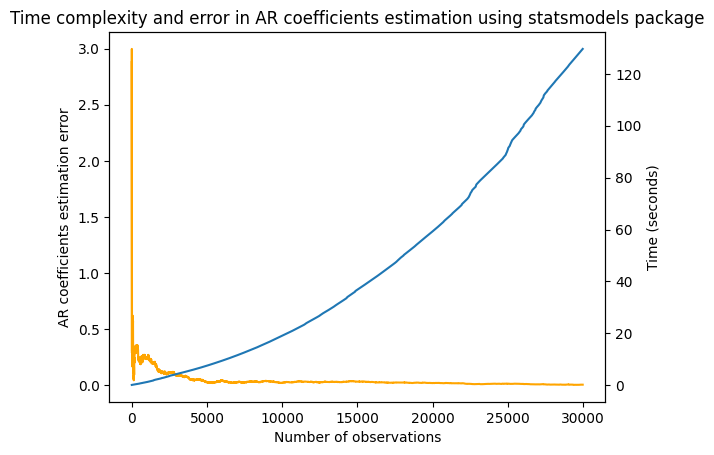

In [15]:

import matplotlib.pyplot as plt

plt.plot(errors, color='orange')
plt.ylabel('AR coefficients estimation error')
plt.xlabel('Number of observations')

ax1 = plt.twinx()
ax1.plot(times)
ax1.set_ylabel('Time (seconds)')

plt.title('Time complexity and error in AR coefficients estimation using statsmodels package')
plt.show()

In [16]:
from ctw.models import BivariateARTreeBis, Quantizer
threshold_x = np.linspace(min(data), max(data), 15)
q = Quantizer(thresholds=threshold_x)
tree = BivariateARTreeBis(quantizer_seq=[], x_quantizer=q, y_quantizer=q, order=4, constant_term=True, beta=0.9)

errors = []
times = []
start_time = time.time()
for i in range(len(data)):
    tree.observe(x_new=data[i], y_new=data[i])
    params = tree.tree.root.data['ms']
    error = np.abs(params[0] - coeffs[0]) + np.abs(params[1] - coeffs[1]) + np.abs(params[2] - coeffs[2]) + np.abs(params[3] - coeffs[3])
    errors.append(error)
    end_time = time.time()
    times.append(end_time - start_time)

    

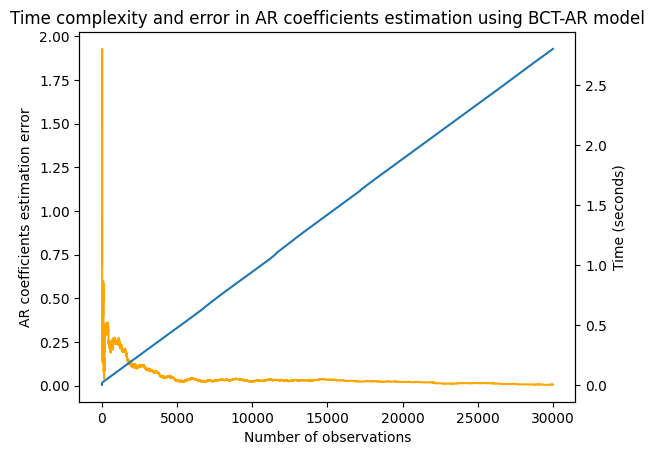

In [18]:
import matplotlib.pyplot as plt

plt.plot(errors, color='orange')
plt.ylabel('AR coefficients estimation error')
plt.xlabel('Number of observations')

ax1 = plt.twinx()
ax1.plot(times)
ax1.set_ylabel('Time (seconds)')

plt.title('Time complexity and error in AR coefficients estimation using BCT-AR model')
plt.show()